In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("data/Eurecom ElasticMon 5G/01-RawDatasets/stablelongdistance.csv")

# Aperçu
print(df.head())

print(df.shape)

                    _id             _index  _score _type  \
0  wxTJnWcBxEP08HZRNvtc  dataset-mac_stats     NaN  json   
1  whTJnWcBxEP08HZRNvtc  dataset-mac_stats     NaN  json   
2  wRTJnWcBxEP08HZRNvtc  dataset-mac_stats     NaN  json   
3  wBTJnWcBxEP08HZRNvtc  dataset-mac_stats     NaN  json   
4  vxTJnWcBxEP08HZRNvtc  dataset-mac_stats     NaN  json   

                          date_time  \
0  December 11th 2018, 17:01:47.051   
1  December 11th 2018, 17:01:47.001   
2  December 11th 2018, 17:01:46.951   
3  December 11th 2018, 17:01:46.901   
4  December 11th 2018, 17:01:46.851   

                                           mac_stats  
0  [{"agent_id":2,"eNBId":234881024,"ue_mac_stats...  
1  [{"agent_id":2,"eNBId":234881024,"ue_mac_stats...  
2  [{"agent_id":2,"eNBId":234881024,"ue_mac_stats...  
3  [{"agent_id":2,"eNBId":234881024,"ue_mac_stats...  
4  [{"agent_id":2,"eNBId":234881024,"ue_mac_stats...  
(5794, 6)


In [2]:
print(df.isnull().sum())

_id             0
_index          0
_score       5794
_type           0
date_time       0
mac_stats       0
dtype: int64


In [3]:
df = df.drop(columns=['_index'])

In [4]:
# Valeurs manquantes
df = df.fillna(df.median(numeric_only=True))

# Suppression doublons
df = df.drop_duplicates()

# Normalisation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.shape)

(5794, 5)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:1047: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:1052: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/extmath.py:1072: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [5]:
import pandas as pd
import ast

# =========================================================
# Charger le CSV original
# =========================================================
df = pd.read_csv("data/Eurecom ElasticMon 5G/01-RawDatasets/stablelongdistance.csv")

# =========================================================
# Fonction de flatten du JSON contenu dans mac_stats
# =========================================================
def extract_features(row):

    try:
        # Conversion string -> objet Python
        data = ast.literal_eval(row["mac_stats"])

        # Premier élément
        item = data[0]

        # ue_mac_stats
        ue = item["ue_mac_stats"][0]

        # raccourcis
        mac_stats_root = ue["mac_stats"]

        dl_cqi = mac_stats_root.get("dlCqiReport", {})
        ul_cqi = mac_stats_root.get("ulCqiReport", {})
        rrc = mac_stats_root.get("rrcMeasurements", {})
        pdcp = mac_stats_root.get("pdcpStats", {})
        mac = mac_stats_root.get("macStats", {})

        # wbCqi
        try:
            wbcqi = dl_cqi["csiReport"][0]["p10csi"]["wbCqi"]
        except:
            wbcqi = None

        # macSdusDl
        try:
            mac_sdu_length = mac["macSdusDl"][0]["sduLength"]
            mac_sdu_lcid = mac["macSdusDl"][0]["lcid"]
        except:
            mac_sdu_length = None
            mac_sdu_lcid = None

        # Construction de la ligne flattenée
        return pd.Series({

            "date_index": row["date_time"],

            "rsrp": rrc.get("pcellRsrp"),
            "rsrq": rrc.get("pcellRsrq"),

            "wbcqi": wbcqi,

            "macStats_phr": mac_stats_root.get("phr"),

            "dlCqiReport_sfnSn": dl_cqi.get("sfnSn"),

            "macStats_totalBytesSdusDl":
                mac.get("totalBytesSdusDl"),

            "macStats_totalTbsUl":
                mac.get("totalTbsUl"),

            "macStats_mcs1Ul":
                mac.get("mcs1Ul"),

            "macStats_totalPduDl":
                mac.get("totalPduDl"),

            "macStats_totalBytesSdusUl":
                mac.get("totalBytesSdusUl"),

            "macStats_tbsDl":
                mac.get("tbsDl"),

            "macStats_totalPrbUl":
                mac.get("totalPrbUl"),

            "macStats_macSdusDl_sduLength":
                mac_sdu_length,

            "macStats_macSdusDl_lcid":
                mac_sdu_lcid,

            "macStats_prbUl":
                mac.get("prbUl"),

            "macStats_totalPduUl":
                mac.get("totalPduUl"),

            "macStats_mcs1Dl":
                mac.get("mcs1Dl"),

            "macStats_mcs2Dl":
                mac.get("mcs2Dl"),

            "macStats_prbDl":
                mac.get("prbDl"),

            "macStats_totalPrbDl":
                mac.get("totalPrbDl"),

            "macStats_prbRetxDl":
                mac.get("prbRetxDl"),

            "macStats_totalTbsDl":
                mac.get("totalTbsDl"),

            "ulCqiReport_sfnSn":
                ul_cqi.get("sfnSn"),

            "pdcpStats_pktRx":
                pdcp.get("pktRx"),

            "pdcpStats_pktRxW":
                pdcp.get("pktRxW"),

            "pdcpStats_pktRxAiatW":
                pdcp.get("pktRxAiatW"),

            "pdcpStats_pktRxOo":
                pdcp.get("pktRxOo"),

            "pdcpStats_pktRxBytesW":
                pdcp.get("pktRxBytesW"),

            "pdcpStats_pktRxSn":
                pdcp.get("pktRxSn"),

            "pdcpStats_pktTxBytesW":
                pdcp.get("pktTxBytesW"),

            "pdcpStats_pktTxSn":
                pdcp.get("pktTxSn"),

            "pdcpStats_pktTxBytes":
                pdcp.get("pktTxBytes"),

            "pdcpStats_pktRxAiat":
                pdcp.get("pktRxAiat"),

            "pdcpStats_pktRxBytes":
                pdcp.get("pktRxBytes"),

            "pdcpStats_pktTx":
                pdcp.get("pktTx"),

            "pdcpStats_pktTxW":
                pdcp.get("pktTxW"),

            "pdcpStats_pktTxAiatW":
                pdcp.get("pktTxAiatW"),

            "pdcpStats_sfn":
                pdcp.get("sfn"),

            "pdcpStats_pktTxAiat":
                pdcp.get("pktTxAiat"),

            "rnti":
                ue.get("rnti"),

            # à modifier selon votre logique
            "quality":
                None
        })

    except Exception as e:
        print("Erreur :", e)
        return pd.Series()


# =========================================================
# Appliquer l'extraction
# =========================================================
df = df.apply(extract_features, axis=1)

# =========================================================
# Sauvegarde
# =========================================================
df.to_csv("data/Eurecom ElasticMon 5G/03-ISJ_Prepoccessed_data/stable_longDist.csv", index=False)

print(df.head())

                         date_index  rsrp  rsrq  wbcqi  macStats_phr  \
0  December 11th 2018, 17:01:47.051  -119    -8      7             7   
1  December 11th 2018, 17:01:47.001  -119    -8      8             9   
2  December 11th 2018, 17:01:46.951  -119    -8      7            11   
3  December 11th 2018, 17:01:46.901  -119    -8      8            12   
4  December 11th 2018, 17:01:46.851  -119    -8      7            11   

   dlCqiReport_sfnSn  macStats_totalBytesSdusDl  macStats_totalTbsUl  \
0               9379                       8106               840887   
1               9299                       8106               840761   
2               9219                       8106               840698   
3               9139                       8106               840572   
4               9059                       8106               840446   

   macStats_mcs1Ul  macStats_totalPduDl  ...  pdcpStats_pktTxBytes  \
0               10                 1382  ...                 310

In [6]:
df['latency_score'] = (
    df['pdcpStats_pktRxAiat'] +
    df['pdcpStats_pktRxAiatW'] +
    df['pdcpStats_pktTxAiatW']
)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

# =========================================================
# Features
# =========================================================
features = [
    'rsrq',
    'rsrp',
    'wbcqi',
    'macStats_totalPrbDl',
    'macStats_prbRetxDl',
    'pdcpStats_pktRxAiat',
    'pdcpStats_pktRxOo',
    'macStats_totalPduDl',
    'macStats_tbsDl',
    'ulCqiReport_sfnSn'
]

# =========================================================
# Variables
# =========================================================
X = df[features]
y = df['latency_score']

# =========================================================
# Split train/test
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# Modèle Random Forest
# =========================================================
model_latency = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# =========================================================
# Entraînement
# =========================================================
model_latency.fit(X_train, y_train)


# Sauvegarder le modèle
joblib.dump(model_latency, "models/model_latency.pkl")
# =========================================================
# Prédictions
# =========================================================
preds = model_latency.predict(X_test)

# =========================================================
# Évaluation
# =========================================================
mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 22.12745166092555


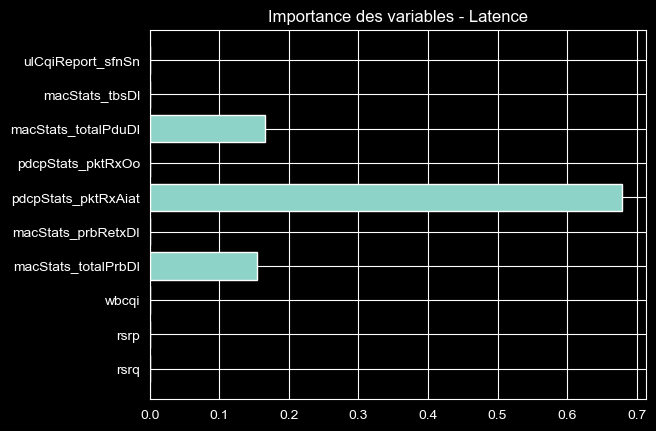

In [10]:
import matplotlib.pyplot as plt

importance = model_latency.feature_importances_

plt.barh(features, importance)
plt.title("Importance des variables - Latence")
plt.show()

## MODELE 2 — Réduction consommation énergétique

In [11]:
df['energy_score'] = (
    df['macStats_totalPrbDl'] +
    df['macStats_totalPrbUl'] +
    df['macStats_totalBytesSdusDl'] +
    df['macStats_totalBytesSdusUl']
)

In [19]:
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

# =========================
# FEATURES
# =========================
energy_features = [
    'macStats_totalPrbDl',
    'macStats_totalPrbUl',
    'macStats_prbDl',
    'macStats_prbUl',
    'macStats_mcs1Dl',
    'macStats_mcs1Ul',
    'macStats_totalBytesSdusDl',
    'macStats_totalBytesSdusUl',
    'rsrp',
    'macStats_phr'
]

# =========================
# DATA
# =========================
X = df[energy_features]
y = df['energy_score']

# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MODEL
# =========================
energy_model = LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05
)

# =========================
# TRAINING
# =========================
energy_model.fit(X_train, y_train)

# Sauvegarder le modèle
joblib.dump(model_latency, "models/energy_model.pkl")
# =========================
# PREDICTION
# =========================
preds = energy_model.predict(X_test)

# =========================
# EVALUATION
# =========================
mae = mean_absolute_error(y_test, preds)
print(f"MAE : {mae:.2f}")

# ==========================================================
# FONCTION DE RECOMMANDATION D'ACTIONS ENERGETIQUES
# ==========================================================
def recommend_action(row, predicted_score):

    prb_dl = row['macStats_prbDl']
    prb_ul = row['macStats_prbUl']

    traffic_dl = row['macStats_totalBytesSdusDl']
    traffic_ul = row['macStats_totalBytesSdusUl']

    mcs_dl = row['macStats_mcs1Dl']
    mcs_ul = row['macStats_mcs1Ul']

    phr = row['macStats_phr']

    # ======================================================
    # REGLES METIER
    # ======================================================

    # 1. PRB élevés -> Sleep mode cellules
    if prb_dl > 80 or prb_ul > 80:
        return "Activer le sleep mode des cellules"

    # 2. Trafic faible -> Shutdown dynamique
    elif traffic_dl < 1000 and traffic_ul < 1000:
        return "Activer le shutdown dynamique"

    # 3. MCS inefficace -> Adaptation modulation
    elif mcs_dl < 5 or mcs_ul < 5:
        return "Adapter la modulation et le codage"

    # 4. UE énergivore -> Power control
    elif phr < 10:
        return "Appliquer un power control"

    # 5. Score énergétique très élevé
    elif predicted_score > 80:
        return "Optimisation énergétique urgente"

    # 6. Score moyen
    elif predicted_score > 50:
        return "Optimisation énergétique modérée"

    # 7. Situation normale
    else:
        return "Fonctionnement normal"

# ==========================================================
# GENERATION DES ACTIONS
# ==========================================================
results = X_test.copy()

results['predicted_energy_score'] = preds

results['recommended_action'] = results.apply(
    lambda row: recommend_action(
        row,
        row['predicted_energy_score']
    ),
    axis=1
)

# ==========================================================
# AFFICHAGE DES RESULTATS
# ==========================================================
print(results[
    [
        'predicted_energy_score',
        'recommended_action'
    ]
].head(10))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035975 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1067
[LightGBM] [Info] Number of data points in the train set: 4635, number of used features: 7
[LightGBM] [Info] Start training from score 3229310.488673
MAE : 471.66
      predicted_energy_score                recommended_action
4939            3.003215e+06        Appliquer un power control
2910            3.230105e+06  Optimisation énergétique urgente
1033            3.440013e+06  Optimisation énergétique urgente
5383            2.953483e+06        Appliquer un power control
156             3.538019e+06  Optimisation énergétique urgente
586             3.490003e+06  Optimisation énergétique urgente
3837            3.124946e+06  Optimisation énergétique urgente
561             3.493303e+06  Optimisation énergétique urgente
626             3.486330e+06  Optimisation énergétique urgente
2218       

 ## MODELE 3 — Réduction coûts de maintenance

In [14]:
from sklearn.ensemble import IsolationForest
import joblib

maintenance_features = [
    'rsrp',
    'rsrq',
    'macStats_prbRetxDl',
    'pdcpStats_pktRxOo',
    'pdcpStats_pktRxAiat',
    'macStats_totalPduDl',
    'macStats_totalPduUl',
    'wbcqi',
    'macStats_totalTbsDl',
    'macStats_totalTbsUl'
]

X = df[maintenance_features]

maintenance_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

maintenance_model.fit(X)
# Sauvegarder le modèle
joblib.dump(model_latency, "models/maintenance_model.pkl")

df['anomaly'] = maintenance_model.predict(X)

print(df['anomaly'].value_counts())

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


anomaly
 1    5504
-1     290
Name: count, dtype: int64


In [15]:
anomalies = df[df['anomaly'] == -1]

print(anomalies.head())

                         date_index  rsrp  rsrq  wbcqi  macStats_phr  \
0  December 11th 2018, 17:01:47.051  -119    -8      7             7   
2  December 11th 2018, 17:01:46.951  -119    -8      7            11   
4  December 11th 2018, 17:01:46.851  -119    -8      7            11   
5  December 11th 2018, 17:01:46.801  -118    -8      7             8   
6  December 11th 2018, 17:01:46.751  -118    -8      7            10   

   dlCqiReport_sfnSn  macStats_totalBytesSdusDl  macStats_totalTbsUl  \
0               9379                       8106               840887   
2               9219                       8106               840698   
4               9059                       8106               840446   
5               8979                       8104               840383   
6               8899                       8104               840257   

   macStats_mcs1Ul  macStats_totalPduDl  ...  pdcpStats_pktTx  \
0               10                 1382  ...               86   
2   